# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

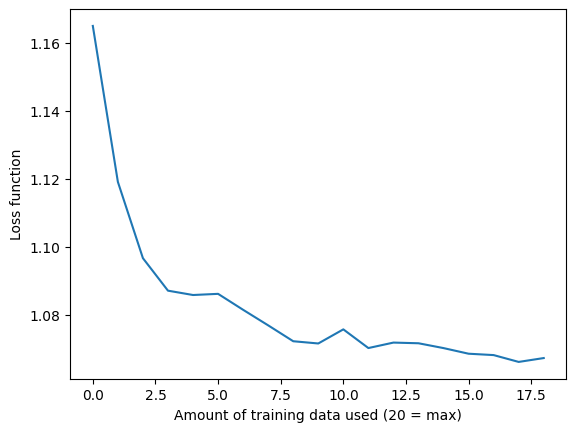

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

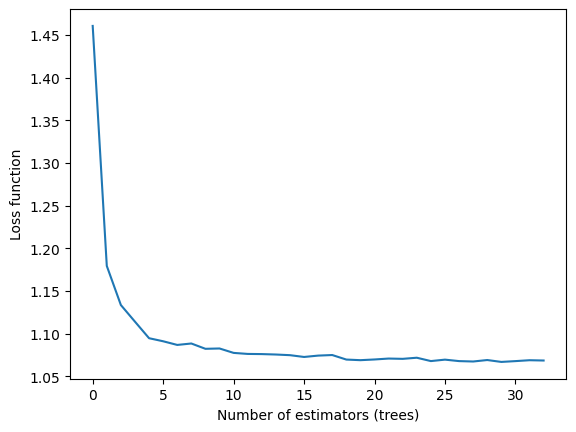

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

**Answer** 
I would cut the plot showing the number of estimators. The plot using the amount of training data is more interesting and important because it shows how model performance improves as more information becomes available. This has stronger practical value, since collecting more data can meaningfully affect prediction quality. The number of estimators is still relevant, but it is more of a tuning detail, while training data size tells a broader story about model learning. If only one variable should remain on the x-axis, I would keep the amount of training data used.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [9]:
import pandas as pd
import numpy as np
import os
import kagglehub

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Download datasets
path_conversion = kagglehub.dataset_download("rabieelkharoua/predict-conversion-in-digital-marketing-dataset")

# Load dataset
conversion = pd.read_csv(os.path.join(path_conversion, "digital_marketing_campaign_dataset.csv"))

# Check it worked
print(conversion.head())

# Make a copy
df = conversion.copy()

# Convert target to binary if needed
# Adjust this line if your target column is already 0/1
# Example assumes "Conversion" is the target
y = df["Conversion"]
X = df.drop(columns=["Conversion"])

# One-hot encode categorical variables if any
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Base random forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Cross-validation
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="f1")
print("\nCross-validation F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

# Hyperparameter tuning
param_dist = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

rs.fit(X_train, y_train)

print("\nBest Parameters:", rs.best_params_)

best_rf = rs.best_estimator_
best_pred = best_rf.predict(X_test)

print("\nTuned Model Performance")
print("Accuracy:", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred))
print("Recall:", recall_score(y_test, best_pred))
print("F1-score:", f1_score(y_test, best_pred))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


   CustomerID  Age  Gender  Income CampaignChannel CampaignType      AdSpend  \
0        8000   56  Female  136912    Social Media    Awareness  6497.870068   
1        8001   69    Male   41760           Email    Retention  3898.668606   
2        8002   46  Female   88456             PPC    Awareness  1546.429596   
3        8003   32  Female   44085             PPC   Conversion   539.525936   
4        8004   60  Female   83964             PPC   Conversion  1678.043573   

   ClickThroughRate  ConversionRate  WebsiteVisits  PagesPerVisit  TimeOnSite  \
0          0.043919        0.088031              0       2.399017    7.396803   
1          0.155725        0.182725             42       2.917138    5.352549   
2          0.277490        0.076423              2       8.223619   13.794901   
3          0.137611        0.088004             47       4.540939   14.688363   
4          0.252851        0.109940              0       2.046847   13.993370   

   SocialShares  EmailOpens  Ema

A random forest classifier was used to predict conversion outcomes in the marketing dataset. The model achieved an accuracy of 0.891 and an F1-score of 0.941, indicating strong overall performance. Precision and recall were also high, showing that the model is effective at identifying conversion cases.
However, the classification report shows weaker performance for the non-conversion class, suggesting that the dataset is imbalanced. This is further supported by cross-validation results, where most folds performed well but one fold performed poorly, lowering the average F1-score.
After hyperparameter tuning, the best model used 100 trees with a maximum depth of 15. The tuned model performed similarly to the original model, suggesting that the model already captured most of the meaningful patterns in the data. Overall, the model is effective but is influenced by class imbalance.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

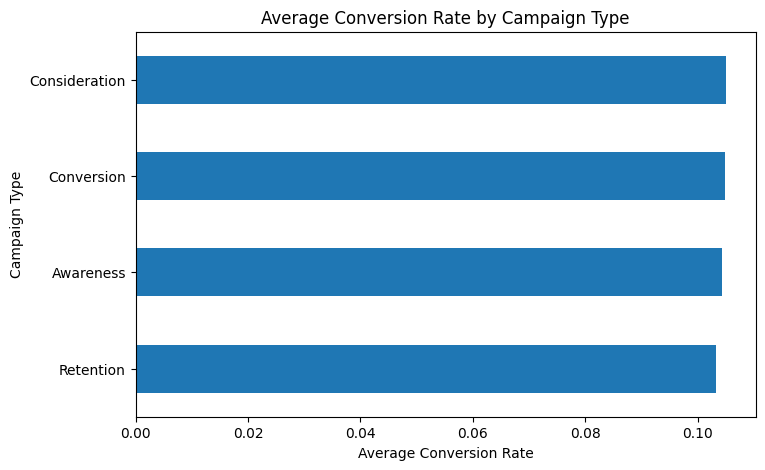

In [10]:

avg_conversion = conversion.groupby("CampaignType")["ConversionRate"].mean().sort_values()

plt.figure(figsize=(8,5))
avg_conversion.plot(kind="barh")
plt.title("Average Conversion Rate by Campaign Type")
plt.xlabel("Average Conversion Rate")
plt.ylabel("Campaign Type")
plt.show()

This chart was designed in a cleaner storytelling style by simplifying the layout and focusing attention on the comparison between campaign types. The horizontal bar chart makes it easier to compare average conversion rates across categories and keeps the message visually clear.